# Proyek Akhir: Sistem Prediksi Risiko Dropout Mahasiswa Jaya Jaya Institut

- Nama: Septa Bagas Setyawan
- Email: septabagas.2023@student.iny.ac.id
- Id Dicoding: CDCC015D6Y2100

## Persiapan

### Menyiapkan library yang dibutuhkan

In [471]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import os

import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

### Menyiapkan data yang akan diguankan

In [472]:
df = pd.read_csv('/content/data.csv', delimiter=";")

## Data Understanding

In [473]:
df.shape

(4424, 37)

In [474]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [475]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [476]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [477]:
df.isna().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [478]:
print('Data Duplicated :', df.duplicated().sum())

Data Duplicated : 0


In [479]:
df["Status"].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


In [480]:
df["Status"].value_counts(normalize=True).mul(100).round(2)

,proportion
Status,
Graduate,49.93
Dropout,32.12
Enrolled,17.95


## Data Preparation / Preprocessing

### Labeling

In [481]:
Marital_map = {
    1: "single",
    2: "married",
    3: "widower",
    4: "divorced",
    5: "facto union",
    6: "legally separated"
}

df['Marital_status_label'] = df['Marital_status'].map(Marital_map)

In [482]:
Gender_map = {
    0: 'Female',
    1: 'Male'
}

df['Gender_label'] = df['Gender'].map(Gender_map)

In [483]:
Tuition_fees_up_to_date_map = {
    0: "No",
    1: "Yes"
}

df['Tuition_fees_up_to_date_label'] = df['Tuition_fees_up_to_date'].map(Tuition_fees_up_to_date_map)

In [484]:
Displaced_map = {
    0: "No",
    1: "Yes"
}

df['Displaced_label'] = df['Displaced'].map(Displaced_map)


In [485]:
Educational_special_needs_map = {
    0: "No",
    1: "Yes"
}

df['Educational_special_needs_label'] = df['Educational_special_needs'].map(Educational_special_needs_map)

In [486]:
Scholarship_holder_map = {
    0: "No",
    1: "Yes"
}

df['Scholarship_holder_label'] = df['Scholarship_holder'].map(Scholarship_holder_map)

In [487]:
Debtor_map = {
    0: "No",
    1: "Yes"
}

df['Debtor_label'] = df['Debtor'].map(Debtor_map)

In [488]:
Daytime_evening_attendance_map = {
    0: "evening",
    1: "daytime"
}

df['Daytime_evening_attendance_label'] = df['Daytime_evening_attendance'].map(Daytime_evening_attendance_map)

In [489]:
International_map = {
    0: "No",
    1: "Yes"
}

df['International_label'] = df['International'].map(International_map)

In [490]:
Previous_map = {
    1: "Secondary education",
    2: "Higher education - bachelor's degree",
    3: "Higher education - degree",
    4: "Higher education - master's",
    5: "Higher education - doctorate",
    6: "Frequency of higher education",
    9: "12th year of schooling - not completed",
    10: "11th year of schooling - not completed",
    12: "Other - 11th year of schooling",
    14: "10th year of schooling",
    15: "10th year of schooling - not completed",
    19: "Basic education 3rd cycle (9th/10th/11th year) or equiv.",
    38: "Basic education 2nd cycle (6th/7th/8th year) or equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)"
}

df['Previous_qualification_label'] = df['Previous_qualification'].map(Previous_map)

In [491]:
Nacionality_map = {

      1: "Portuguese",
      2: "German",
      6: "Spanish",
      11: "Italian",
      13: "Dutch",
      14: "English",
      17: "Lithuanian",
      21: "Angolan",
      22: "Cape Verdean",
      24: "Guinean",
      25: "Mozambican",
      26: "Santomean",
      32: "Turkish",
      41: "Brazilian",
      62: "Romanian",
      100: "Moldova (Republic of)",
      101: "Mexican",
      103: "Ukrainian",
      105: "Russian",
      108: "Cuban",
      109: "Colombian"
}

df['Nacionality_label'] = df['Nacionality'].map(Nacionality_map)

In [492]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Marital_status_label,Gender_label,Tuition_fees_up_to_date_label,Displaced_label,Educational_special_needs_label,Scholarship_holder_label,Debtor_label,Daytime_evening_attendance_label,International_label,Previous_qualification_label,Nacionality_label
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,single,Male,Yes,Yes,No,No,No,daytime,No,Secondary education,Portuguese
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,single,Male,No,Yes,No,No,No,daytime,No,Secondary education,Portuguese
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,single,Male,No,Yes,No,No,No,daytime,No,Secondary education,Portuguese
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,single,Female,Yes,Yes,No,No,No,daytime,No,Secondary education,Portuguese
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,married,Female,Yes,No,No,No,No,evening,No,Secondary education,Portuguese


### Exploratory Data Analysis (EDA)

#### Distribusi Status

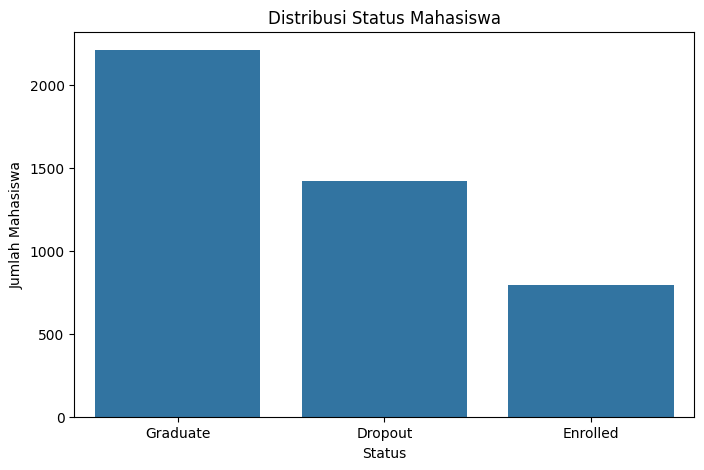

In [493]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Status",
    order=df["Status"].value_counts().index
)

plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

#### Performa Akademik

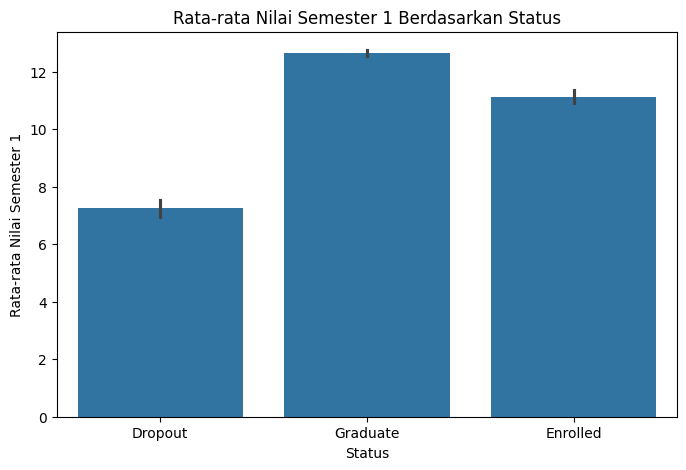

In [494]:
df.groupby("Status")[
    "Curricular_units_1st_sem_grade"
].mean().sort_values()


plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_grade"
)

plt.title("Rata-rata Nilai Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Rata-rata Nilai Semester 1")
plt.show()

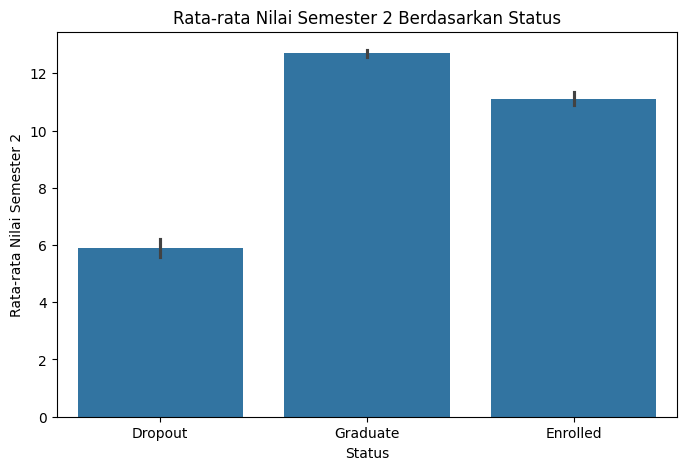

In [495]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_grade"
)

plt.title("Rata-rata Nilai Semester 2 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Rata-rata Nilai Semester 2")
plt.show()

#### Mata Kuliah Disetujui

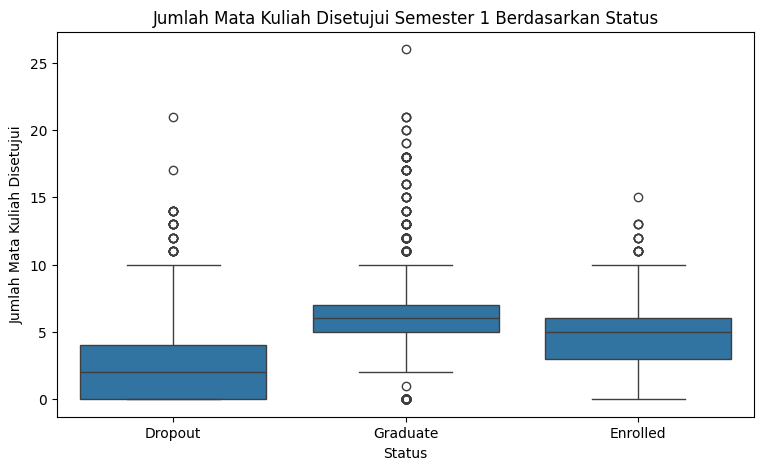

In [496]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_1st_sem_approved"
)

plt.title(
    "Jumlah Mata Kuliah Disetujui Semester 1 Berdasarkan Status"
)

plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")

plt.show()

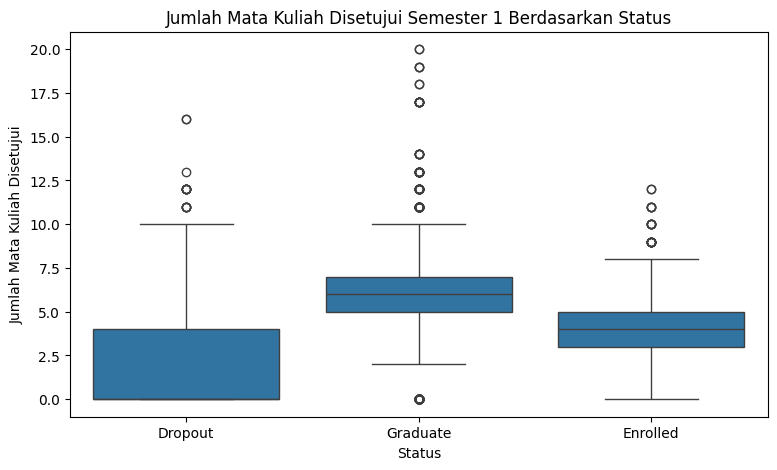

In [497]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Status",
    y="Curricular_units_2nd_sem_approved"
)

plt.title(
    "Jumlah Mata Kuliah Disetujui Semester 1 Berdasarkan Status"
)

plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")

plt.show()

#### Faktor Finansial

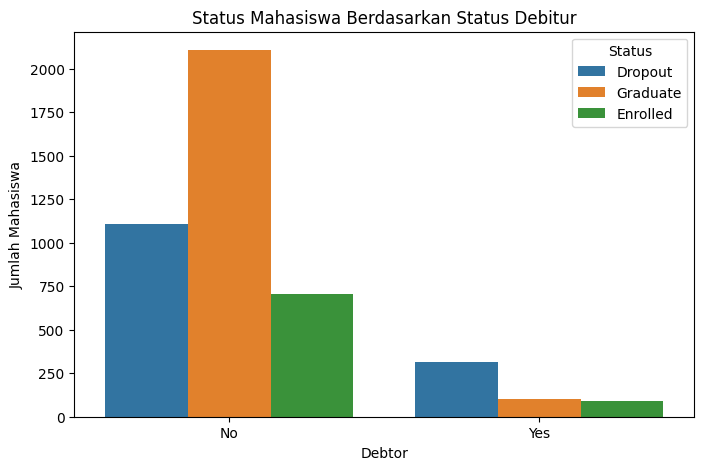

In [498]:
pd.crosstab(
    df["Debtor"],
    df["Status"],
    normalize="index"
).mul(100).round(2)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Debtor_label",
    hue="Status"
)

plt.title("Status Mahasiswa Berdasarkan Status Debitur")
plt.xlabel("Debtor")
plt.ylabel("Jumlah Mahasiswa")

plt.show()

## Modeling

### Feature & Target

In [499]:
# Menentukan target
y = df["Status"]

# Kolom label tambahan untuk kebutuhan EDA/dashboard tidak digunakan sebagai fitur model
label_columns = [col for col in df.columns if col.endswith("_label")]

# Menentukan fitur
X = df.drop(columns=["Status"] + label_columns)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi target:")
print(y.value_counts())

Shape X: (4424, 36)
Shape y: (4424,)

Distribusi target:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### Train-Test Split

In [500]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (3539, 36)
Data testing : (885, 36)


### Preprocessing Pipeline

In [501]:
categorical_columns = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("Jumlah fitur kategorikal:", len(categorical_columns))
print("Jumlah fitur numerik:", len(numerical_columns))

Jumlah fitur kategorikal: 17
Jumlah fitur numerik: 19


In [502]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

In [503]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

model_pipeline.fit(X_train, y_train)
print("Model berhasil dilatih.")

Model berhasil dilatih.


In [504]:
y_pred = model_pipeline.predict(X_test)

print("10 prediksi pertama:")
for actual, predicted in zip(y_test.iloc[:10], y_pred[:10]):
    print(f"Aktual: {actual} | Prediksi: {predicted}")

10 prediksi pertama:
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Enrolled | Prediksi: Dropout
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate
Aktual: Graduate | Prediksi: Graduate


## Evaluation

In [505]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.7650
Precision: 0.7487
Recall   : 0.7650
F1-Score : 0.7470


In [506]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       284
    Enrolled       0.57      0.32      0.41       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



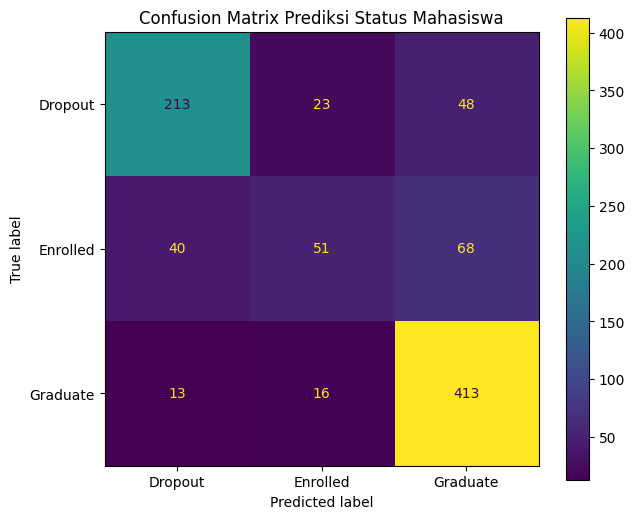

In [507]:
labels = ["Dropout", "Enrolled", "Graduate"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix Prediksi Status Mahasiswa")
plt.show()

## Analisis Feature Importance

In [508]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = model_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

,Feature,Importance
13,num__Curricular_units_2nd_sem_approved,0.090437
14,num__Curricular_units_2nd_sem_grade,0.077166
7,num__Curricular_units_1st_sem_approved,0.061421
8,num__Curricular_units_1st_sem_grade,0.056504
12,num__Curricular_units_2nd_sem_evaluations,0.040290
6,num__Curricular_units_1st_sem_evaluations,0.036966
2,num__Admission_grade,0.036768
3,num__Age_at_enrollment,0.032723
1,num__Previous_qualification_grade,0.032483
237,cat__Tuition_fees_up_to_date_1,0.023132


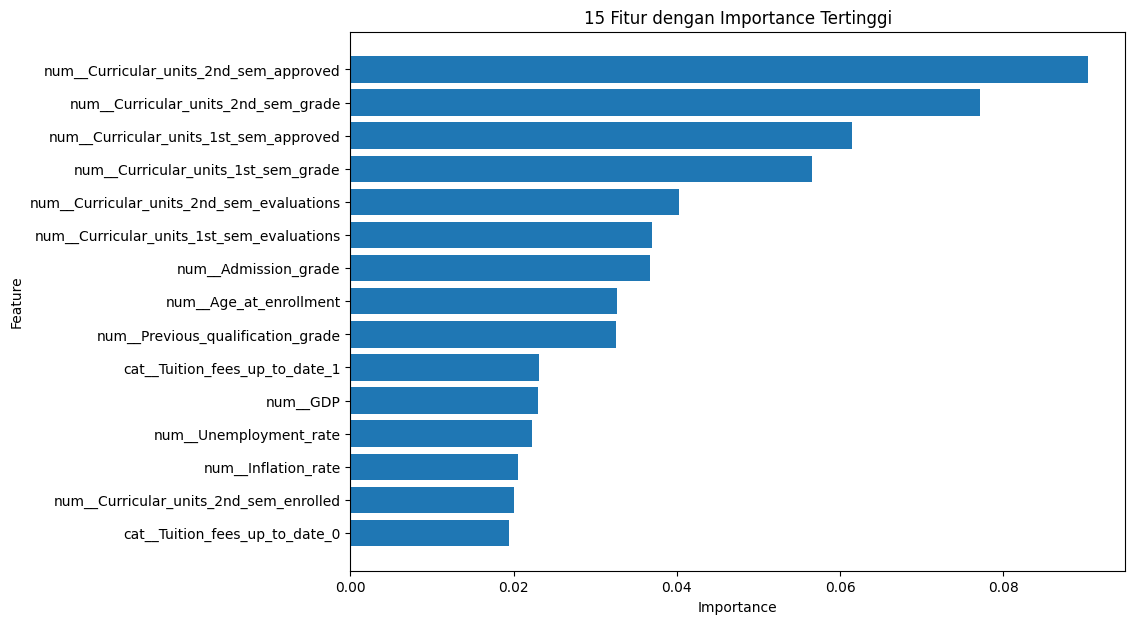

In [509]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.title("15 Fitur dengan Importance Tertinggi")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Simpan Model

In [510]:
os.makedirs("model", exist_ok=True)

model_path = "model/dropout_prediction_pipeline.pkl"

joblib.dump(
    model_pipeline,
    model_path
)

print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: model/dropout_prediction_pipeline.pkl


In [511]:
# Verifikasi bahwa model hasil penyimpanan dapat dimuat kembali
loaded_model = joblib.load("model/dropout_prediction_pipeline.pkl")

test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Model berhasil dimuat kembali.")

Model berhasil dimuat kembali.


In [512]:
dashboard_df = df.copy()

# Contoh ekspor dataset yang siap digunakan untuk dashboard
dashboard_df.to_csv("dashboard_data.csv", index=False)

print("File dashboard_data.csv berhasil dibuat.")

File dashboard_data.csv berhasil dibuat.
